# 01 — Exploratory data analysis (EDA)



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

# Giữ tiêu đề, nhãn hàng và ô dữ liệu thẳng hàng khi bảng có nội dung nhiều dòng.
display(HTML('''
<style>
.dataframe th, .dataframe td { vertical-align: middle !important; }
.dataframe thead th { text-align: center !important; }
.dataframe tbody th { text-align: left !important; white-space: nowrap; }
</style>
'''))

# Cho phép chạy từ thư mục gốc dự án hoặc từ notebooks/.
CANDIDATE_ROOTS = [Path.cwd().resolve(), Path.cwd().resolve().parent]
PROJECT_ROOT = next(
    (root for root in CANDIDATE_ROOTS
     if (root / 'data' / 'processed' / 'credit_card_clients_clean.csv').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Không tìm thấy data/processed/credit_card_clients_clean.csv.')

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'credit_card_clients_clean.csv'
FIG_DIR = PROJECT_ROOT / 'reports' / 'eda'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTHS = ['sep', 'aug', 'jul', 'jun', 'may', 'apr']
PAY_COLS = [f'pay_{month}' for month in MONTHS]
BILL_COLS = [f'bill_amt_{month}' for month in MONTHS]
PAY_AMT_COLS = [f'pay_amt_{month}' for month in MONTHS]
TARGET = 'default_next_month'

def save_figure(filename):
    """Lưu biểu đồ nhất quán và đóng figure để không hiển thị lặp lại."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()

df = pd.read_csv(DATA_PATH)
print(f'Dữ liệu: {DATA_PATH.relative_to(PROJECT_ROOT)}')
print(f'Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột')
df.head()

Dữ liệu: data\processed\credit_card_clients_clean.csv
Kích thước: 30,000 dòng × 24 cột


,limit_bal,gender,education,marriage,age,pay_sep,pay_aug,pay_jul,pay_jun,pay_may,pay_apr,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1. Thống kê mô tả và kiểu dữ liệu

In [2]:
dtype_summary = (df.dtypes.astype(str).value_counts()
                 .rename_axis('dtype').reset_index(name='số_cột'))

print('Kiểu dữ liệu của các cột:')
display(dtype_summary)

print('Kiểu dữ liệu theo cột:')
display(df.dtypes.rename('dtype').to_frame())

# percentiles giúp quan sát độ lệch và các giá trị cực trị.
print('Độ lệch và các giá trị cực trị:')
display(df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

Kiểu dữ liệu của các cột:


,dtype,số_cột
0,int64,24


Kiểu dữ liệu theo cột:


,dtype
limit_bal,int64
gender,int64
education,int64
marriage,int64
age,int64
pay_sep,int64
pay_aug,int64
pay_jul,int64
pay_jun,int64
pay_may,int64


Độ lệch và các giá trị cực trị:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
limit_bal,"30,000.00","167,484.32","129,747.66","10,000.00","10,000.00","20,000.00","50,000.00","140,000.00","240,000.00","430,000.00","500,000.00","1,000,000.00"
gender,"30,000.00",1.60,0.49,1.00,1.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00
education,"30,000.00",1.85,0.79,0.00,1.00,1.00,1.00,2.00,2.00,3.00,5.00,6.00
marriage,"30,000.00",1.55,0.52,0.00,1.00,1.00,1.00,2.00,2.00,2.00,3.00,3.00
age,"30,000.00",35.49,9.22,21.00,22.00,23.00,28.00,34.00,41.00,53.00,60.00,79.00
pay_sep,"30,000.00",-0.02,1.12,-2.00,-2.00,-2.00,-1.00,0.00,0.00,2.00,3.00,8.00
pay_aug,"30,000.00",-0.13,1.20,-2.00,-2.00,-2.00,-1.00,0.00,0.00,2.00,3.00,8.00
pay_jul,"30,000.00",-0.17,1.20,-2.00,-2.00,-2.00,-1.00,0.00,0.00,2.00,3.00,8.00
pay_jun,"30,000.00",-0.22,1.17,-2.00,-2.00,-2.00,-1.00,0.00,0.00,2.00,3.00,8.00
pay_may,"30,000.00",-0.27,1.13,-2.00,-2.00,-2.00,-1.00,0.00,0.00,2.00,3.00,8.00


## 2. Giá trị thiếu và thiếu ngầm

`NaN` chỉ là một dạng thiếu. Bảng thứ hai kiểm tra giá trị bằng 0: với `limit_bal`, `age`, `gender` và nhãn đích, 0 là bất thường; với `education`/`marriage`, 0 không có trong mô tả; còn 0 ở các cột sao kê/thanh toán có thể là một giá trị nghiệp vụ hợp lệ và được giữ để phân tích tiếp.

In [3]:
print('Số thiếu và tỉ lệ thiếu của các cột:')
missing = pd.DataFrame({
    'số_thiếu': df.isna().sum(),
    'tỷ_lệ_thiếu_%': (df.isna().mean() * 100).round(3),
}).sort_values(['số_thiếu', 'tỷ_lệ_thiếu_%'], ascending=False)
display(missing)
print('Kết luận:', 'Có giá trị thiếu.' if missing['số_thiếu'].sum() else 'Không có giá trị thiếu dạng NaN.')

zero_check = pd.DataFrame({
    'số_giá_trị_0': (df == 0).sum(),
    'tỷ_lệ_0_%': ((df == 0).mean() * 100).round(2),
})
zero_check['đánh_giá'] = 'cần xem xét là thiếu ngầm'
zero_check.loc[BILL_COLS + PAY_AMT_COLS + PAY_COLS, 'đánh_giá'] = 'có thể hợp lệ theo nghiệp vụ'
zero_check.loc[['education', 'marriage'], 'đánh_giá'] = 'ngoài mô tả - xem mục mã'
zero_check.loc[['limit_bal', 'age', 'gender'], 'đánh_giá'] = '0 là không hợp lệ, có thể là thiếu ngầm'
zero_check.loc[TARGET, 'đánh_giá'] = '0 là nhãn (không vỡ nợ), không phải thiếu'
display(zero_check.sort_values('số_giá_trị_0', ascending=False))

Số thiếu và tỉ lệ thiếu của các cột:


,số_thiếu,tỷ_lệ_thiếu_%
limit_bal,0,0.00
gender,0,0.00
education,0,0.00
marriage,0,0.00
age,0,0.00
pay_sep,0,0.00
pay_aug,0,0.00
pay_jul,0,0.00
pay_jun,0,0.00
pay_may,0,0.00


Kết luận: Không có giá trị thiếu dạng NaN.


,số_giá_trị_0,tỷ_lệ_0_%,đánh_giá
default_next_month,23364,77.88,"0 là nhãn (không vỡ nợ), không phải thiếu"
pay_may,16947,56.49,có thể hợp lệ theo nghiệp vụ
pay_jun,16455,54.85,có thể hợp lệ theo nghiệp vụ
pay_apr,16286,54.29,có thể hợp lệ theo nghiệp vụ
pay_jul,15764,52.55,có thể hợp lệ theo nghiệp vụ
pay_aug,15730,52.43,có thể hợp lệ theo nghiệp vụ
pay_sep,14737,49.12,có thể hợp lệ theo nghiệp vụ
pay_amt_apr,7173,23.91,có thể hợp lệ theo nghiệp vụ
pay_amt_may,6703,22.34,có thể hợp lệ theo nghiệp vụ
pay_amt_jun,6408,21.36,có thể hợp lệ theo nghiệp vụ


## 3. Đối chiếu mã với tài liệu

Theo tài liệu UCI: `gender ∈ {1,2}`, `education ∈ {1,2,3,4}`, `marriage ∈ {1,2,3}`, và `PAY_* ∈ {-1,1,…,9}`. Các mã quan sát nhưng không thuộc các tập này được liệt kê đầy đủ bên dưới; đây là cảnh báo chất lượng/mã hoá, không phải bằng chứng tự động rằng bản ghi bị lỗi.

In [2]:
# Make this section runnable independently from the setup cell.
if 'pd' not in globals():
    import pandas as pd

if 'display' not in globals():
    from IPython.display import display

if 'df' not in globals():
    from pathlib import Path

    candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    data_path = next(
        (root / 'data' / 'processed' / 'credit_card_clients_clean.csv'
         for root in candidate_roots
         if (root / 'data' / 'processed' / 'credit_card_clients_clean.csv').exists()),
        None,
    )
    if data_path is None:
        raise FileNotFoundError('Không tìm thấy data/processed/credit_card_clients_clean.csv.')
    df = pd.read_csv(data_path)

if 'PAY_COLS' not in globals():
    MONTHS = ['sep', 'aug', 'jul', 'jun', 'may', 'apr']
    PAY_COLS = [f'pay_{month}' for month in MONTHS]

DOCUMENTED_CODES = {
    'education': {1, 2, 3, 4},
    'marriage': {1, 2, 3},
    **{column: {-1, *range(1, 10)} for column in PAY_COLS},
}

missing_columns = sorted(set(DOCUMENTED_CODES) - set(df.columns))
if missing_columns:
    raise KeyError(f'Thiếu cột để đối chiếu mã: {missing_columns}')

code_audit = []
for column, documented in DOCUMENTED_CODES.items():
    counts = df[column].value_counts(dropna=False).sort_index()
    observed = set(counts.index.dropna())
    outside = sorted(observed - documented)
    code_audit.append({
        'cột': column,
        'mã_theo_tài_liệu': sorted(documented),
        'mã_quan_sát': sorted(observed),
        'mã_ngoài_mô_tả': outside,
        'số_dòng_mã_ngoài_mô_tả': int(counts.loc[outside].sum()) if outside else 0,
    })
    print(f'\n{column} — value_counts')
    display(counts.rename('số_dòng').to_frame())

code_audit = pd.DataFrame(code_audit)
display(code_audit)


education — value_counts


,số_dòng
education,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51



marriage — value_counts


,số_dòng
marriage,
0,54
1,13659
2,15964
3,323



pay_sep — value_counts


...


pay_may — value_counts


,số_dòng
pay_may,
-2,4546
-1,5539
0,16947
2,2626
3,178
4,84
5,17
6,4
7,58



pay_apr — value_counts


,số_dòng
pay_apr,
-2,4895
-1,5740
0,16286
2,2766
3,184
4,49
5,13
6,19
7,46


,cột,mã_theo_tài_liệu,mã_quan_sát,mã_ngoài_mô_tả,số_dòng_mã_ngoài_mô_tả
0,education,"[1, 2, 3, 4]","[0, 1, 2, 3, 4, 5, 6]","[0, 5, 6]",345
1,marriage,"[1, 2, 3]","[0, 1, 2, 3]",[0],54
2,pay_sep,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[-2, 0]",17496
3,pay_aug,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[-2, 0]",19512
4,pay_jul,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[-2, 0]",19849
5,pay_jun,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[-2, 0]",20803
6,pay_may,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]","[-2, 0]",21493
7,pay_apr,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]","[-2, 0]",21181


## 4. Ngoại lai và phân phối giao dịch

Dùng quy tắc IQR như một cờ sàng lọc, không mặc định xoá các giá trị bị gắn cờ. Hạn mức và số tiền thường lệch phải; số dư âm cũng được thống kê riêng vì có thể phản ánh điều chỉnh/hoàn tiền.

,cột,min,p01,p99,max,ngưỡng_dưới_IQR,ngưỡng_trên_IQR,số_dòng_gắn_cờ_IQR,tỷ_lệ_gắn_cờ_%
0,age,21,22.00,60.00,79,8.50,60.50,272,0.91
1,limit_bal,10000,"10,000.00","500,000.00",1000000,"-235,000.00","525,000.00",167,0.56
2,bill_amt_sep,-165580,-81.00,"350,110.68",964511,"-91,739.62","162,389.38",2400,8.00
3,bill_amt_aug,-69777,-200.00,"337,495.28",983931,"-88,547.50","155,538.50",2395,7.98
4,bill_amt_jul,-157264,-200.00,"325,030.39",1664089,"-83,581.50","146,412.50",2469,8.23
5,bill_amt_jun,-170000,-212.02,"304,997.27",891586,"-75,942.12","132,774.88",2622,8.74
6,bill_amt_may,-81334,-232.01,"285,868.33",927171,"-70,878.25","122,831.75",2725,9.08
7,bill_amt_apr,-339603,-331.03,"279,505.06",961664,"-70,657.38","121,111.62",2693,8.98
8,pay_amt_sep,0,0.00,"66,522.18",873552,"-5,009.00","11,015.00",2745,9.15
9,pay_amt_aug,0,0.00,"76,651.02",1684259,"-5,417.50","11,250.50",2714,9.05


Số dư âm và giá trị rất lớn (p99/max):


,số_dư_âm,tỷ_lệ_âm_%,p99,max
bill_amt_sep,590,1.97,"350,110.68",964511
bill_amt_aug,669,2.23,"337,495.28",983931
bill_amt_jul,655,2.18,"325,030.39",1664089
bill_amt_jun,675,2.25,"304,997.27",891586
bill_amt_may,655,2.18,"285,868.33",927171
bill_amt_apr,688,2.29,"279,505.06",961664


Tần suất thanh toán bằng 0:


,số_thanh_toán_bằng_0,tỷ_lệ_bằng_0_%
pay_amt_sep,5249,17.50
pay_amt_aug,5396,17.99
pay_amt_jul,5968,19.89
pay_amt_jun,6408,21.36
pay_amt_may,6703,22.34
pay_amt_apr,7173,23.91


C:\Users\WIN11\AppData\Local\Temp\ipykernel_16964\70196854.py:37: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['age'], vert=False)


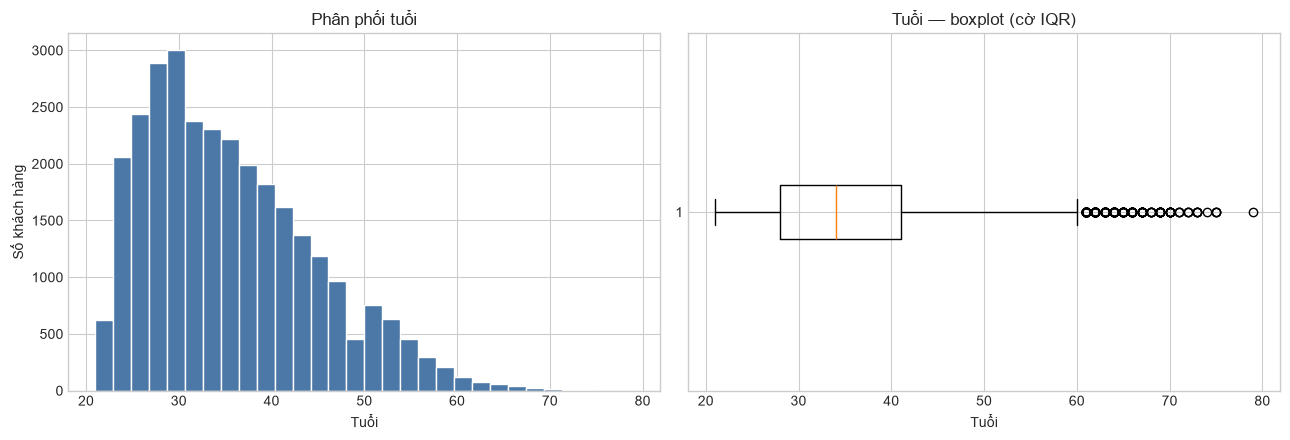

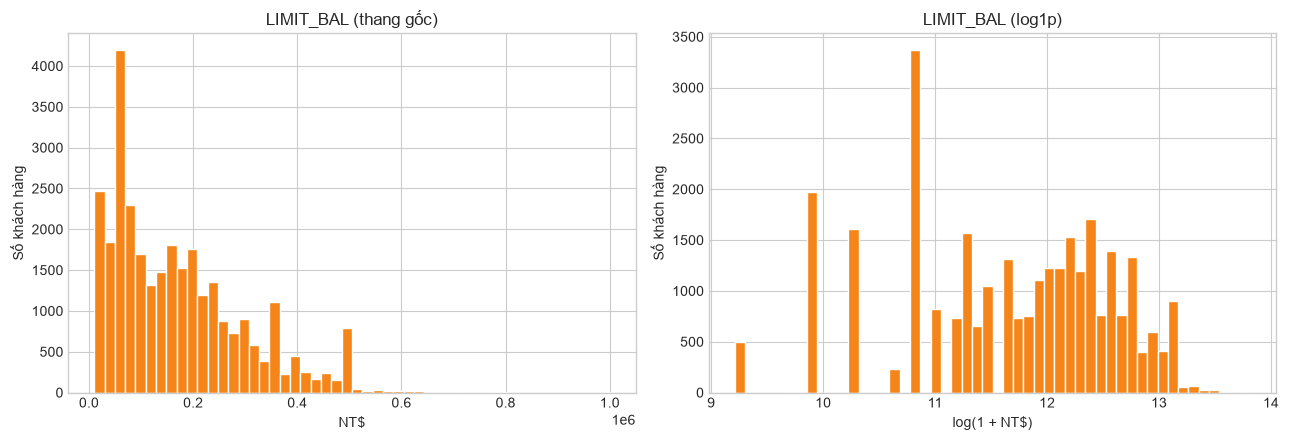

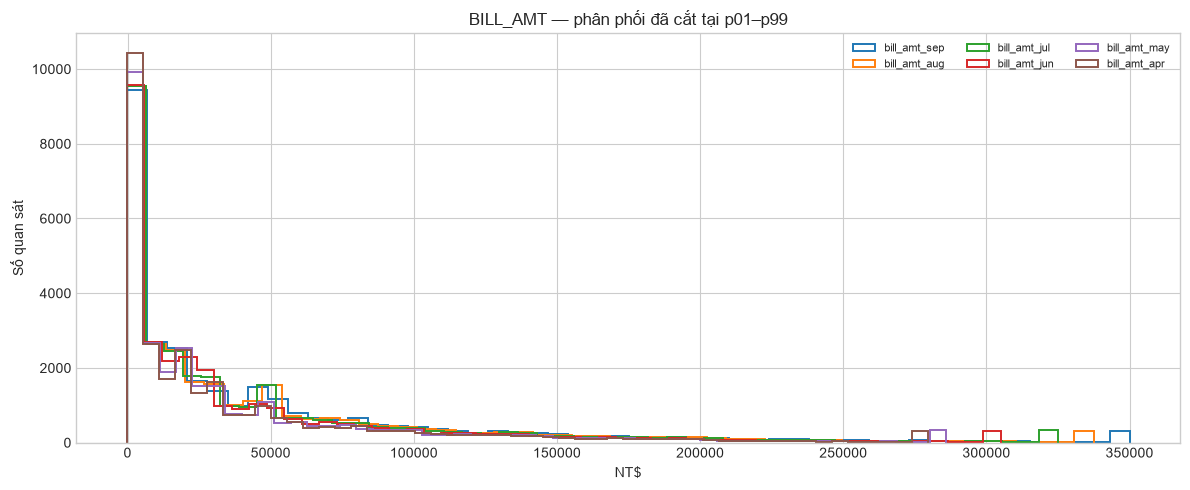

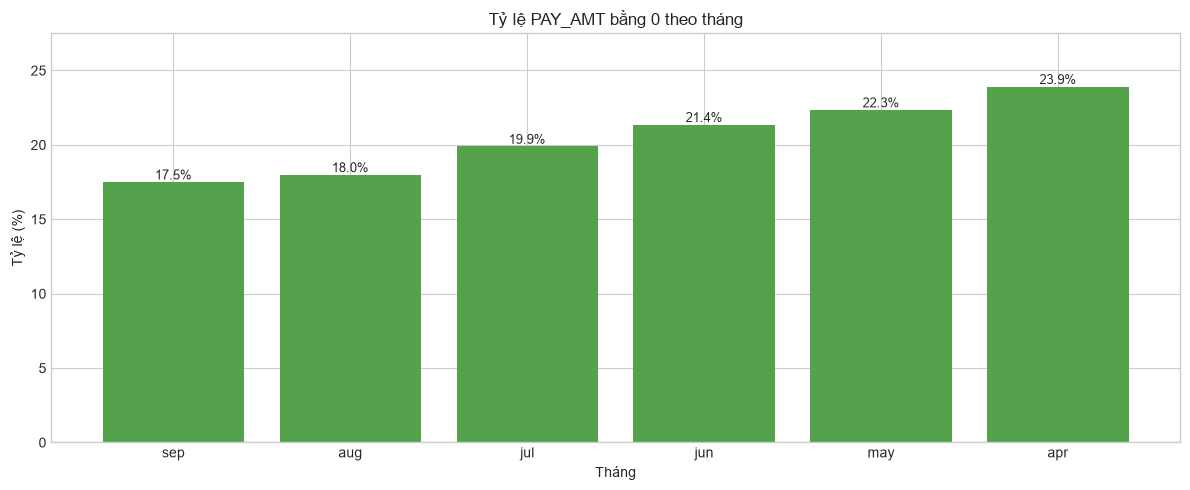

In [5]:
def iqr_summary(frame, columns):
    rows = []
    for column in columns:
        q1, q3 = frame[column].quantile([.25, .75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = (frame[column] < lower) | (frame[column] > upper)
        rows.append({
            'cột': column, 'min': frame[column].min(), 'p01': frame[column].quantile(.01),
            'p99': frame[column].quantile(.99), 'max': frame[column].max(),
            'ngưỡng_dưới_IQR': lower, 'ngưỡng_trên_IQR': upper,
            'số_dòng_gắn_cờ_IQR': int(flagged.sum()), 'tỷ_lệ_gắn_cờ_%': round(flagged.mean() * 100, 2),
        })
    return pd.DataFrame(rows)

display(iqr_summary(df, ['age', 'limit_bal'] + BILL_COLS + PAY_AMT_COLS))

bill_flags = pd.DataFrame({
    'số_dư_âm': (df[BILL_COLS] < 0).sum(),
    'tỷ_lệ_âm_%': ((df[BILL_COLS] < 0).mean() * 100).round(2),
    'p99': df[BILL_COLS].quantile(.99),
    'max': df[BILL_COLS].max(),
})
print('Số dư âm và giá trị rất lớn (p99/max):')
display(bill_flags)

zero_payments = pd.DataFrame({
    'số_thanh_toán_bằng_0': (df[PAY_AMT_COLS] == 0).sum(),
    'tỷ_lệ_bằng_0_%': ((df[PAY_AMT_COLS] == 0).mean() * 100).round(2),
})
print('Tần suất thanh toán bằng 0:')
display(zero_payments)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df['age'], bins=30, color='#4C78A8', edgecolor='white')
axes[0].set(title='Phân phối tuổi', xlabel='Tuổi', ylabel='Số khách hàng')
axes[1].boxplot(df['age'], vert=False)
axes[1].set(title='Tuổi — boxplot (cờ IQR)', xlabel='Tuổi')
save_figure('01_age_outliers.png')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df['limit_bal'], bins=50, color='#F58518', edgecolor='white')
axes[0].set(title='LIMIT_BAL (thang gốc)', xlabel='NT$', ylabel='Số khách hàng')
axes[1].hist(np.log1p(df['limit_bal']), bins=50, color='#F58518', edgecolor='white')
axes[1].set(title='LIMIT_BAL (log1p)', xlabel='log(1 + NT$)', ylabel='Số khách hàng')
save_figure('02_limit_bal_distribution.png')

fig, ax = plt.subplots(figsize=(12, 5))
for column in BILL_COLS:
    ax.hist(np.clip(df[column], df[column].quantile(.01), df[column].quantile(.99)), bins=50, histtype='step', linewidth=1.4, label=column)
ax.set(title='BILL_AMT — phân phối đã cắt tại p01–p99', xlabel='NT$', ylabel='Số quan sát')
ax.legend(ncol=3, fontsize=8)
save_figure('03_bill_amount_distributions.png')

fig, ax = plt.subplots(figsize=(12, 5))
zero_rates = (df[PAY_AMT_COLS] == 0).mean().mul(100)
ax.bar(zero_rates.index.str.replace('pay_amt_', ''), zero_rates, color='#54A24B')
ax.set(title='Tỷ lệ PAY_AMT bằng 0 theo tháng', xlabel='Tháng', ylabel='Tỷ lệ (%)', ylim=(0, max(zero_rates.max() * 1.15, 1)))
for index, value in enumerate(zero_rates):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
save_figure('04_zero_payment_rates.png')

## 5. Dòng trùng lặp và mất cân bằng lớp

Dòng trùng lặp trên toàn bộ 24 cột: 35 (0.12%)


,số_khách_hàng,tỷ_lệ_%
vỡ_nợ,,
0,23364,77.88
1,6636,22.12


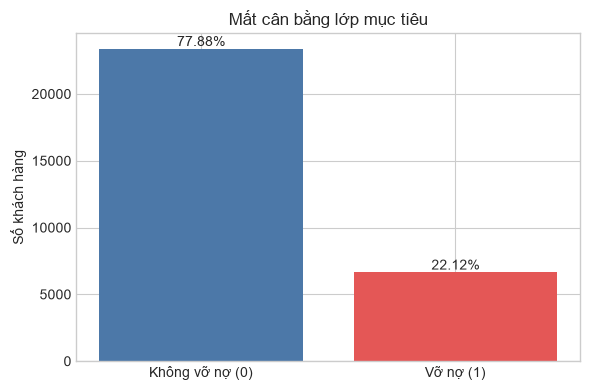

In [6]:
duplicate_count = int(df.duplicated().sum())
print(f'Dòng trùng lặp trên toàn bộ {df.shape[1]} cột: {duplicate_count:,} ({duplicate_count / len(df):.2%})')

class_summary = (df[TARGET].value_counts().sort_index().rename_axis('vỡ_nợ')
                 .to_frame('số_khách_hàng'))
class_summary['tỷ_lệ_%'] = (class_summary['số_khách_hàng'] / len(df) * 100).round(2)
display(class_summary)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Không vỡ nợ (0)', 'Vỡ nợ (1)'], class_summary['số_khách_hàng'], color=['#4C78A8', '#E45756'])
ax.set(title='Mất cân bằng lớp mục tiêu', ylabel='Số khách hàng')
for bar, rate in zip(bars, class_summary['tỷ_lệ_%']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{rate:.2f}%', ha='center', va='bottom')
save_figure('05_class_balance.png')

## 6. So sánh nhóm vỡ nợ và không vỡ nợ

Tổng hợp tiền theo sáu tháng để so sánh rõ hơn giữa hai nhóm, đồng thời giữ `limit_bal` và `age` ở đơn vị gốc. Các boxplot hiển thị đến p99 để một vài giá trị cực lớn không che khuất phần lớn phân phối.

age        limit_bal            total_bill             \
                   median  mean     median       mean     median       mean   
default_next_month                                                            
0                   34.00 35.42 150,000.00 178,099.73 128,660.50 272,428.91   
1                   34.00 35.73  90,000.00 130,109.66 118,688.00 260,822.96   

                   total_payment            
                          median      mean  
default_next_month                          
0                      16,524.00 34,969.42  
1                       9,674.50 19,969.29

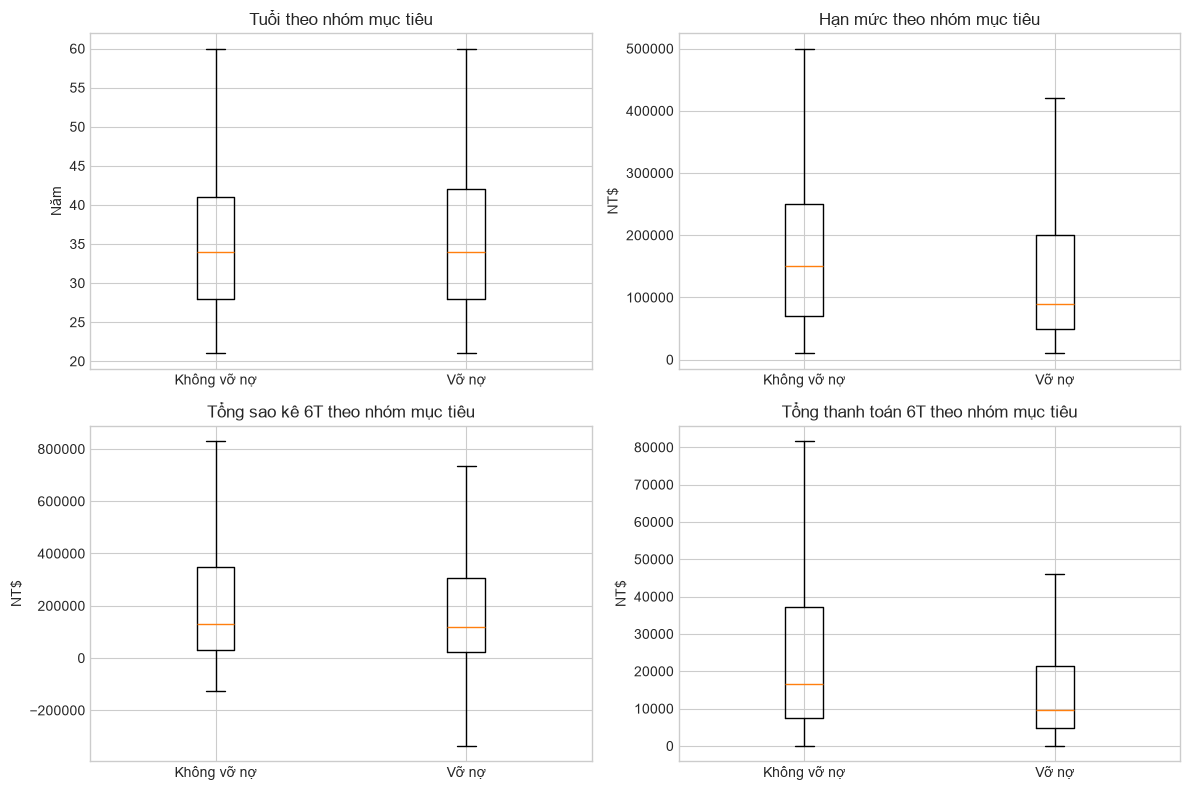

In [7]:
comparison = df.assign(
    total_bill=df[BILL_COLS].sum(axis=1),
    total_payment=df[PAY_AMT_COLS].sum(axis=1),
)
group_summary = comparison.groupby(TARGET)[['age', 'limit_bal', 'total_bill', 'total_payment']].agg(['median', 'mean'])
display(group_summary)

metrics = ['age', 'limit_bal', 'total_bill', 'total_payment']
labels = ['Tuổi', 'Hạn mức', 'Tổng sao kê 6T', 'Tổng thanh toán 6T']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric, label in zip(axes.flat, metrics, labels):
    groups = [comparison.loc[comparison[TARGET] == value, metric] for value in [0, 1]]
    upper = comparison[metric].quantile(.99)
    ax.boxplot([np.clip(group, None, upper) for group in groups], tick_labels=['Không vỡ nợ', 'Vỡ nợ'], showfliers=False)
    ax.set(title=label + ' theo nhóm mục tiêu', ylabel='NT$' if metric != 'age' else 'Năm')
save_figure('06_default_vs_nondefault_distributions.png')

## 7. Tỷ lệ vỡ nợ theo trạng thái trả nợ, nhân khẩu học và tuổi

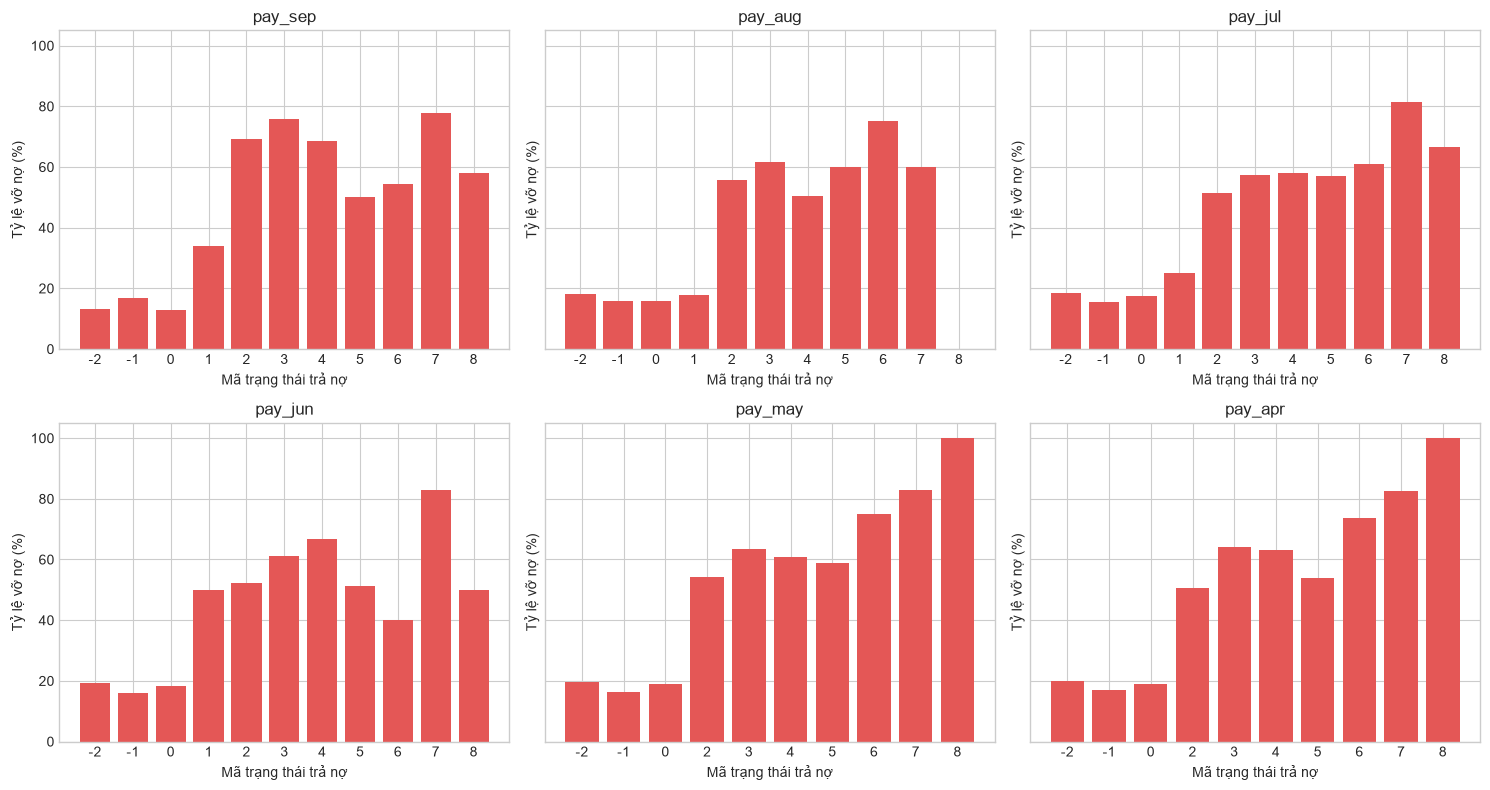


Tỷ lệ vỡ nợ theo pay_sep:


,tỷ_lệ_vỡ_nợ,số_khách_hàng
pay_sep,,
-2,13.23,2759
-1,16.78,5686
0,12.81,14737
1,33.95,3688
2,69.14,2667
3,75.78,322
4,68.42,76
5,50.00,26
6,54.55,11



Tỷ lệ vỡ nợ theo pay_aug:


,tỷ_lệ_vỡ_nợ,số_khách_hàng
pay_aug,,
-2,18.27,3782
-1,15.97,6050
0,15.91,15730
1,17.86,28
2,55.61,3927
3,61.66,326
4,50.51,99
5,60.00,25
6,75.00,12



Tỷ lệ vỡ nợ theo pay_jul:


...


Tỷ lệ vỡ nợ theo education:


,tỷ_lệ_vỡ_nợ,số_khách_hàng
education,,
0,0.00,14
1,19.23,10585
2,23.73,14030
3,25.16,4917
4,5.69,123
5,6.43,280
6,15.69,51



Tỷ lệ vỡ nợ theo marriage:


,tỷ_lệ_vỡ_nợ,số_khách_hàng
marriage,,
0,9.26,54
1,23.47,13659
2,20.93,15964
3,26.01,323


,tỷ_lệ_vỡ_nợ,số_khách_hàng
age_group,,
21–29,22.84,9618
30–39,20.25,11238
40–49,22.97,6464
50–59,24.86,2341
60+,28.32,339


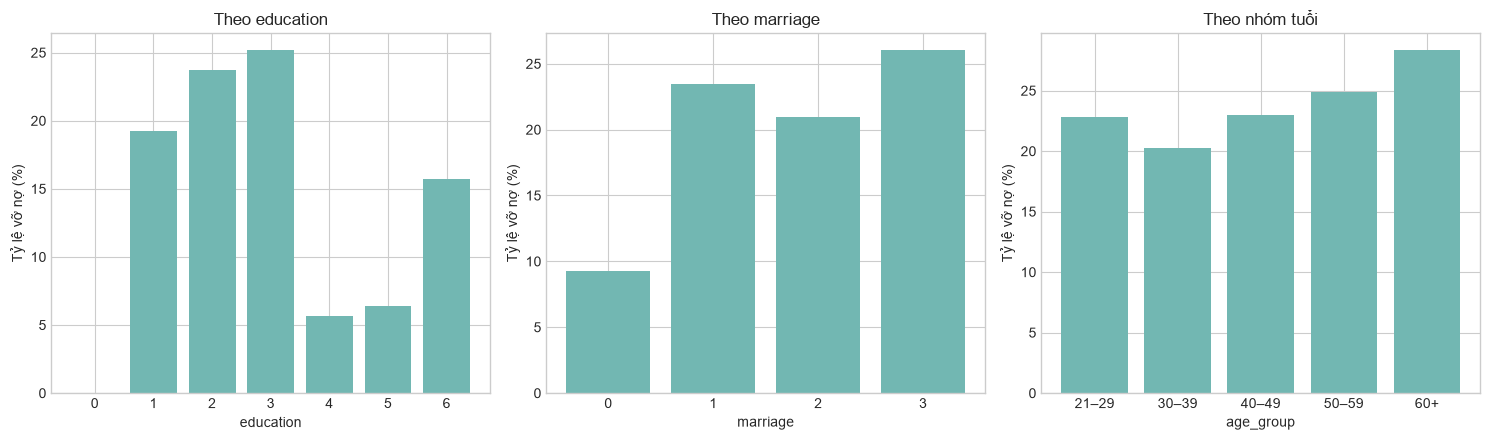

In [8]:
def default_rate(frame, column):
    return (frame.groupby(column, observed=False)[TARGET].agg(['mean', 'size'])
            .rename(columns={'mean': 'tỷ_lệ_vỡ_nợ', 'size': 'số_khách_hàng'})
            .assign(tỷ_lệ_vỡ_nợ=lambda x: x['tỷ_lệ_vỡ_nợ'] * 100))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, column in zip(axes.flat, PAY_COLS):
    rates = default_rate(df, column)
    ax.bar(rates.index.astype(str), rates['tỷ_lệ_vỡ_nợ'], color='#E45756')
    ax.set(title=column, xlabel='Mã trạng thái trả nợ', ylabel='Tỷ lệ vỡ nợ (%)')
save_figure('07_default_rate_by_pay_status.png')

for column in PAY_COLS + ['education', 'marriage']:
    print(f'\nTỷ lệ vỡ nợ theo {column}:')
    display(default_rate(df, column))

age_bins = [20, 30, 40, 50, 60, np.inf]
age_labels = ['21–29', '30–39', '40–49', '50–59', '60+']
df_age = df.assign(age_group=pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False))
age_rates = default_rate(df_age, 'age_group')
display(age_rates)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, column, title in zip(axes, ['education', 'marriage', 'age_group'], ['Theo education', 'Theo marriage', 'Theo nhóm tuổi']):
    rates = default_rate(df_age if column == 'age_group' else df, column)
    ax.bar(rates.index.astype(str), rates['tỷ_lệ_vỡ_nợ'], color='#72B7B2')
    ax.set(title=title, xlabel=column, ylabel='Tỷ lệ vỡ nợ (%)')
save_figure('08_default_rate_by_demographics.png')

## 8. Tương quan

Ma trận Pearson giúp thấy các cặp biến tuyến tính đồng biến/nghịch biến. Đặc biệt kiểm tra khối `bill_amt_*`: tương quan mạnh giữa các tháng là dấu hiệu đa cộng tuyến cần cân nhắc khi dùng mô hình tuyến tính.

Các cặp BILL_AMT tương quan mạnh nhất:


,,tương_quan
bill_amt_sep,bill_amt_aug,0.95
bill_amt_may,bill_amt_apr,0.95
bill_amt_jun,bill_amt_may,0.94
bill_amt_aug,bill_amt_jul,0.93
bill_amt_jul,bill_amt_jun,0.92
bill_amt_jun,bill_amt_apr,0.90
bill_amt_aug,bill_amt_jun,0.89
bill_amt_sep,bill_amt_jul,0.89
bill_amt_jul,bill_amt_may,0.88
bill_amt_sep,bill_amt_jun,0.86


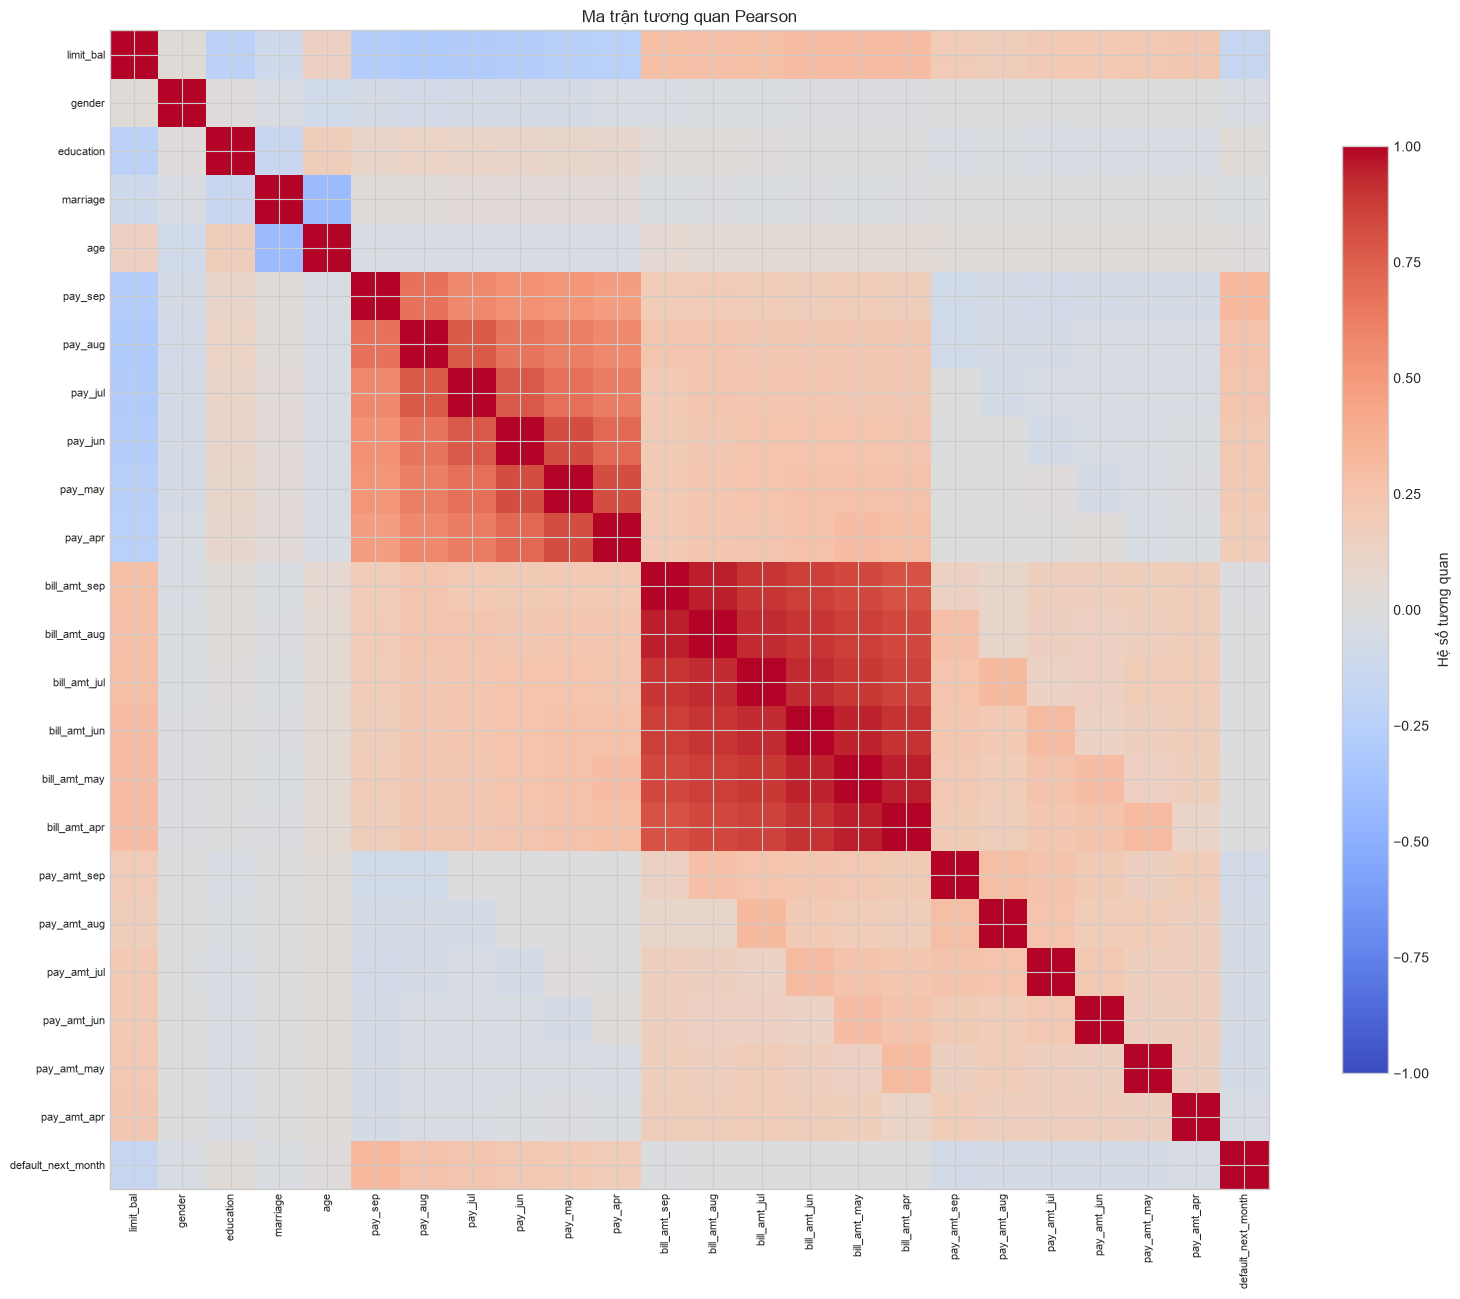

Hoàn tất. Biểu đồ đã lưu tại: reports\eda


In [9]:
correlation = df.corr(numeric_only=True)
bill_correlation = correlation.loc[BILL_COLS, BILL_COLS]
high_bill_pairs = (bill_correlation.where(np.triu(np.ones(bill_correlation.shape), k=1).astype(bool))
                   .stack().sort_values(ascending=False).rename('tương_quan').to_frame())
print('Các cặp BILL_AMT tương quan mạnh nhất:')
display(high_bill_pairs.head(10))

fig, ax = plt.subplots(figsize=(16, 13))
image = ax.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(correlation.index)), correlation.index, fontsize=8)
ax.set_title('Ma trận tương quan Pearson')
fig.colorbar(image, ax=ax, shrink=.8, label='Hệ số tương quan')
save_figure('09_correlation_matrix.png')

print(f'Hoàn tất. Biểu đồ đã lưu tại: {FIG_DIR.relative_to(PROJECT_ROOT)}')